Supervised Learning

Linear Regression

In [2]:
from json import encoder
from threading import main_thread

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv("Boston.csv")

In [3]:
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
x=data.iloc[:,:12].values
y=data.iloc[:,12].values

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [79]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
model.coef_

array([-1.25156811e-01,  4.48575121e-02,  2.01265385e-02, -1.62895522e+01,
        3.77366409e+00, -2.13185120e-03, -1.40611846e+00,  2.66835482e-01,
       -1.21692284e-02, -1.07660161e+00,  8.72533635e-03, -4.94425348e-01])

In [81]:
model.intercept_

np.float64(38.42706211257687)

In [82]:
model.score(x_train,y_train)

0.7690953567794605

In [83]:
model.score(x_train,y_train)*100

76.90953567794605

In [84]:
y_pred=model.predict(x_test)

In [85]:
MSE=mean_squared_error(y_pred,y_test)

In [86]:
MSE

34.21225254753343

In [87]:
RMSE=np.sqrt(MSE)
RMSE

np.float64(5.849124083786685)

In [88]:
x1=np.array([[0.00732,16.0,2.31,0.598,8.575,65.2,4.0800,1,236,17.3,396.90,4.98],[0.00932,12.0,3.31,0.498,6.575,67.2,5.0800,1,266,15.3,396.90,4.98
]])

In [89]:
model.predict(x1)

array([35.70295324, 30.00277067])

In [90]:
x2=np.array([0.00732,16.0,2.31,0.598,8.575,65.2,4.0800,1,236,17.3,396.90,4.98]).reshape(1,12)

In [91]:
model.predict(x2)

array([35.70295324])

Categorical Independent Variables

In [55]:
data=pd.read_csv("GPA_data.CSV")

In [56]:
data.head()

,ID,Gender,Age,Extra_Curricular,Study_Hours,Annual_Income,Distance_From_Home,GPA
0,8867,Male,22,Societies,10,1318792,154,1.76
1,1316,Female,24,Societies,9,874657,181,3.88
2,9443,Male,22,Societies,15,1098331,94,1.73
3,1829,Female,25,No,9,1680585,8,1.29
4,1989,Male,26,No,7,1361560,122,3.19


OneHotEncoder

In [57]:
from sklearn.preprocessing import OneHotEncoder

In [60]:
x=data[['Gender','Extra_Curricular']]
print(x)

     Gender Extra_Curricular
0      Male        Societies
1    Female        Societies
2      Male        Societies
3    Female               No
4      Male               No
..      ...              ...
995  Female               No
996    Male               No
997    Male           Sports
998    Male        Societies
999    Male               No

[1000 rows x 2 columns]


In [59]:
encoder=OneHotEncoder()
x_encoded=encoder.fit_transform(x).toarray()
print(x_encoded)

[[0. 1. 0. 1. 0.]
 [1. 0. 0. 1. 0.]
 [0. 1. 0. 1. 0.]
 ...
 [0. 1. 0. 0. 1.]
 [0. 1. 0. 1. 0.]
 [0. 1. 1. 0. 0.]]


In [94]:
df_dum=pd.get_dummies(data[["Gender","Extra_Curricular"]])
df_dum

,Gender_Female,Gender_Male,Extra_Curricular_No,Extra_Curricular_Societies,Extra_Curricular_Sports
0,False,True,False,True,False
1,True,False,False,True,False
2,False,True,False,True,False
3,True,False,True,False,False
4,False,True,True,False,False
...,...,...,...,...,...
995,True,False,True,False,False
996,False,True,True,False,False
997,False,True,False,False,True
998,False,True,False,True,False


In [95]:
df_dum.drop(["Gender_Female","Extra_Curricular_No"],axis=1,inplace=True)
df_dum

,Gender_Male,Extra_Curricular_Societies,Extra_Curricular_Sports
0,True,True,False
1,False,True,False
2,True,True,False
3,False,False,False
4,True,False,False
...,...,...,...
995,False,False,False
996,True,False,False
997,True,False,True
998,True,True,False


In [96]:
data_new=pd.concat([data,df_dum],axis=1)
data_new.head()

,ID,Gender,Age,Extra_Curricular,Study_Hours,Annual_Income,Distance_From_Home,GPA,Gender_Male,Extra_Curricular_Societies,Extra_Curricular_Sports
0,8867,Male,22,Societies,10,1318792,154,1.76,True,True,False
1,1316,Female,24,Societies,9,874657,181,3.88,False,True,False
2,9443,Male,22,Societies,15,1098331,94,1.73,True,True,False
3,1829,Female,25,No,9,1680585,8,1.29,False,False,False
4,1989,Male,26,No,7,1361560,122,3.19,True,False,False


In [97]:
data_new.drop(["ID","Gender","Extra_Curricular"],axis=1,inplace=True)
data_new.head()

,Age,Study_Hours,Annual_Income,Distance_From_Home,GPA,Gender_Male,Extra_Curricular_Societies,Extra_Curricular_Sports
0,22,10,1318792,154,1.76,True,True,False
1,24,9,874657,181,3.88,False,True,False
2,22,15,1098331,94,1.73,True,True,False
3,25,9,1680585,8,1.29,False,False,False
4,26,7,1361560,122,3.19,True,False,False


Cross Validation Approach

In [98]:
from sklearn.model_selection import cross_val_score

In [99]:
ncvals=cross_val_score(model,x_train,y_train,cv=10,scoring='neg_mean_squared_error')
ncvals

array([-15.1507166 , -16.21354133, -19.8720515 , -22.20787221,
       -18.23202084, -19.26308788, -38.81641962, -30.28243052,
       -22.54464364, -11.89223922])

In [100]:
cvals=-ncvals
cvals

array([15.1507166 , 16.21354133, 19.8720515 , 22.20787221, 18.23202084,
       19.26308788, 38.81641962, 30.28243052, 22.54464364, 11.89223922])

In [101]:
np.sqrt(cvals)

array([3.89239214, 4.02660419, 4.45780793, 4.71252291, 4.26989705,
       4.38897344, 6.23028247, 5.50294744, 4.74812001, 3.44851261])

In [102]:
np.mean(np.sqrt(cvals))

np.float64(4.567806020036128)

Recursive Feature Elimination

In [141]:
from sklearn.feature_selection import RFE,RFECV

In [104]:
rfe=RFE(estimator=LinearRegression(),n_features_to_select=7)

In [105]:
elm_fit=rfe.fit(x_train,y_train)

In [106]:
elm_fit.n_features_

np.int64(7)

In [107]:
elm_fit.support_

array([ True, False, False,  True,  True, False,  True,  True, False,
        True, False,  True])

In [132]:
df_x=data.iloc[:,:12]
df_y=data.iloc[:,12]

In [133]:
df_x.columns

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'black', 'lstat'],
      dtype='str')

In [134]:
selected=df_x.columns[elm_fit.support_]
selected

Index(['crim', 'nox', 'rm', 'dis', 'rad', 'ptratio', 'lstat'], dtype='str')

In [135]:
df_x.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33


In [136]:
df_x1=df_x[selected]
df_x1.head()

,crim,nox,rm,dis,rad,ptratio,lstat
0,0.00632,0.538,6.575,4.0900,1,15.3,4.98
1,0.02731,0.469,6.421,4.9671,2,17.8,9.14
2,0.02729,0.469,7.185,4.9671,2,17.8,4.03
3,0.03237,0.458,6.998,6.0622,3,18.7,2.94
4,0.06905,0.458,7.147,6.0622,3,18.7,5.33


In [137]:
elm_fit.ranking_

array([1, 3, 2, 1, 1, 6, 1, 1, 4, 1, 5, 1])

In [138]:
x=df_x.values
y=df_y.values

In [139]:
x

array([[6.3200e-03, 1.8000e+01, 2.3100e+00, ..., 1.5300e+01, 3.9690e+02,
        4.9800e+00],
       [2.7310e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9690e+02,
        9.1400e+00],
       [2.7290e-02, 0.0000e+00, 7.0700e+00, ..., 1.7800e+01, 3.9283e+02,
        4.0300e+00],
       ...,
       [6.0760e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        5.6400e+00],
       [1.0959e-01, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9345e+02,
        6.4800e+00],
       [4.7410e-02, 0.0000e+00, 1.1930e+01, ..., 2.1000e+01, 3.9690e+02,
        7.8800e+00]], shape=(506, 12))

In [140]:
x1=rfe.fit_transform(x_train,y_train)
x1

array([[ 0.35809,  0.507  ,  6.951  , ...,  8.     , 17.4    ,  9.71   ],
       [ 0.15876,  0.413  ,  5.961  , ...,  4.     , 19.2    ,  9.88   ],
       [ 0.11329,  0.428  ,  6.897  , ...,  6.     , 16.6    , 11.38   ],
       ...,
       [ 0.15098,  0.547  ,  6.021  , ...,  6.     , 17.8    , 10.3    ],
       [ 0.22927,  0.448  ,  6.03   , ...,  3.     , 17.9    , 18.8    ],
       [ 0.13914,  0.51   ,  5.572  , ...,  5.     , 16.6    , 14.69   ]],
      shape=(404, 7))

In [142]:
rfecv=RFECV(estimator=LinearRegression(),min_features_to_select=1,cv=10)

In [143]:
rfecv.fit(x_train,y_train)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearRegression()
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",10
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",None
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [144]:
rfecv.n_features_

np.int64(11)

In [145]:
df_x.columns[rfecv.support_]

Index(['crim', 'zn', 'indus', 'nox', 'rm', 'dis', 'rad', 'tax', 'ptratio',
       'black', 'lstat'],
      dtype='str')

In [148]:
x2=rfecv.fit_transform(x_train,y_train)
x2

array([[3.5809e-01, 0.0000e+00, 6.2000e+00, ..., 1.7400e+01, 3.9170e+02,
        9.7100e+00],
       [1.5876e-01, 0.0000e+00, 1.0810e+01, ..., 1.9200e+01, 3.7694e+02,
        9.8800e+00],
       [1.1329e-01, 3.0000e+01, 4.9300e+00, ..., 1.6600e+01, 3.9125e+02,
        1.1380e+01],
       ...,
       [1.5098e-01, 0.0000e+00, 1.0010e+01, ..., 1.7800e+01, 3.9451e+02,
        1.0300e+01],
       [2.2927e-01, 0.0000e+00, 6.9100e+00, ..., 1.7900e+01, 3.9274e+02,
        1.8800e+01],
       [1.3914e-01, 0.0000e+00, 4.0500e+00, ..., 1.6600e+01, 3.9690e+02,
        1.4690e+01]], shape=(404, 11))

Gradient Descent Algorithm

In [47]:
x = np.array([2600, 3000, 3200, 3600, 4000]).reshape(-1,1)
y = np.array([55000, 56500, 61000, 68000, 72500]).reshape(-1,1)
x=x/x.max()
y=y/y.max()
print(x,y)

[[0.65]
 [0.75]
 [0.8 ]
 [0.9 ]
 [1.  ]] [[0.75862069]
 [0.77931034]
 [0.84137931]
 [0.93793103]
 [1.        ]]


In [48]:
w = 0
b = 0

In [49]:
learning_rate = 0.001
epochs = 100000
mse_list=[]
epochs_list=[]

In [50]:
for i in range(epochs):
    y_pred =( w * x) + b
    error = y - y_pred

    grad_w = -2 * np.mean(error * x)
    grad_b = -2 * np.mean(error)

    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    mse_list.append(np.mean(np.square(error)))
    epochs_list.append(i)

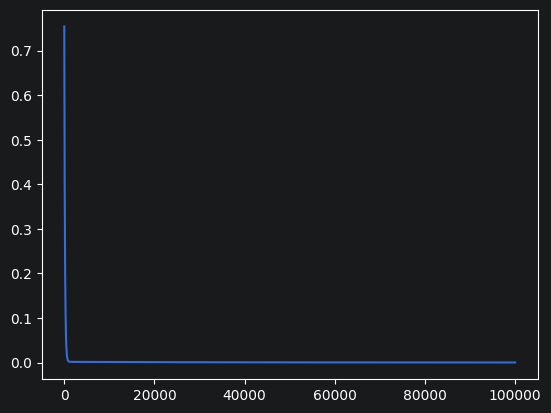

In [51]:
plt.plot(epochs_list,mse_list)

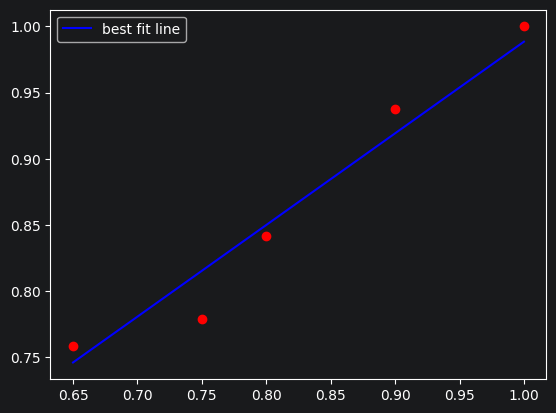

In [52]:
plt.scatter(x,y,color="red")
plt.plot(x,w*x+b,color="blue",label="best fit line")
plt.legend()

Logistic Regression

In [175]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [163]:
data=pd.read_csv("Bank.CSV")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,0
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [164]:
x=data.iloc[:,:7]
y=data.iloc[:,7]

In [165]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [168]:
model = LogisticRegression(max_iter=1000)

In [169]:
model.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [170]:
model.intercept_

array([0.00293026])

In [171]:
model.coef_

array([[ 0.00089077,  0.00454378, -0.56740105,  0.53835135,  0.03881188,
         0.11659175, -0.01033288]])

In [172]:
y_pred=model.predict(x_test)

In [173]:
confusion_matrix(y_test,y_pred)

array([[7155,  170],
       [ 614,  299]])

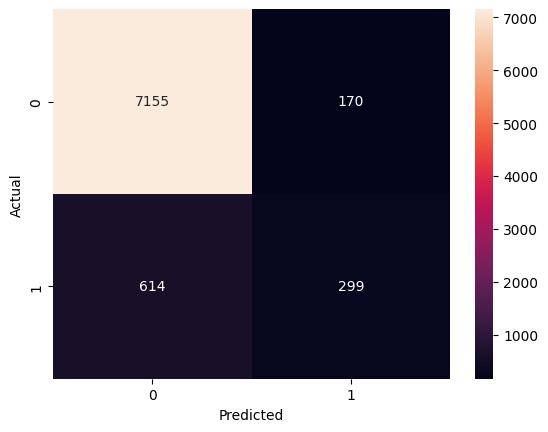

In [179]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt="g")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [180]:
accuracy_score(y_test,y_pred)

0.9048312697256615

In [181]:
1-accuracy_score(y_test,y_pred)

0.09516873027433848

In [182]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7325
           1       0.64      0.33      0.43       913

    accuracy                           0.90      8238
   macro avg       0.78      0.65      0.69      8238
weighted avg       0.89      0.90      0.89      8238



Classification & Regression Trees(CART) | K – Nearest Neighbors (KNN)

In [184]:
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor

In [187]:
data=pd.read_csv("Bank.CSV")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,0
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [188]:
x=data.iloc[:,:7]
y=data.iloc[:,7]

In [189]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [190]:
knnc1=KNeighborsClassifier(n_neighbors=6)

In [191]:
knnc1.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [192]:
y_pred=knnc1.predict(x_test)

In [193]:
accuracy_score(y_test,y_pred)

0.898761835396941

In [194]:
confusion_matrix(y_test,y_pred)

array([[7079,  246],
       [ 588,  325]])

In [195]:
K=range(1,11)
Errors=[]

for k in K:
    knncl=KNeighborsClassifier(n_neighbors=k)
    cvals=1-cross_val_score(knncl,x_train,y_train,cv=10,scoring="accuracy")
    Errors.append(cvals.mean())

print(Errors)

[np.float64(0.11790591805766311), np.float64(0.10631259484066766), np.float64(0.10503793626707132), np.float64(0.10191198786039454), np.float64(0.1006980273141123), np.float64(0.09860394537177543), np.float64(0.097298937784522), np.float64(0.09717754172989379), np.float64(0.09553869499241274), np.float64(0.09666160849772384)]


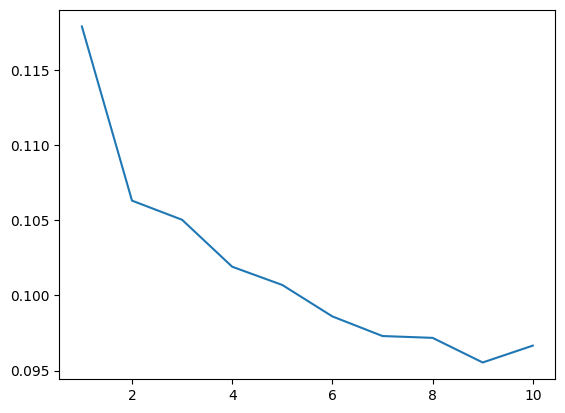

In [196]:
plt.plot(K,Errors)
plt.show()

In [197]:
knnc1=KNeighborsClassifier(n_neighbors=9)

KNeighborsRegressor

In [198]:
data=pd.read_csv("Boston.CSV")
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [205]:
x=data.iloc[:,:12]
y=data.iloc[:,12]

In [206]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [207]:
knnrg=KNeighborsRegressor(n_neighbors=5)

In [208]:
knnrg.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [209]:
y_pred=knnrg.predict(x_test)

In [210]:
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(7.1685161316280634)

Imbalance Data Handling

In [211]:
data=pd.read_csv("Bank_Imbalance.csv")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,1
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,1
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,1
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [212]:
x=data.iloc[:,:7]
y=data.iloc[:,7]

In [213]:
y.value_counts()

y
1    2396
0     603
Name: count, dtype: int64

In [214]:
y.value_counts()/y.value_counts().sum()*100

y
1    79.893298
0    20.106702
Name: count, dtype: float64

In [216]:
from imblearn.over_sampling import SMOTE,ADASYN

In [217]:
smt=SMOTE()

In [218]:
x_sm,y_sm=smt.fit_resample(x,y)

In [219]:
y_sm.value_counts()

y
1    2396
0    2396
Name: count, dtype: int64

In [220]:
x.shape

(2999, 7)

In [221]:
x_sm.shape

(4792, 7)

In [224]:
ada=ADASYN()

In [225]:
x_ad,y_ad=ada.fit_resample(x,y)

In [226]:
y_ad.value_counts()

y
0    2403
1    2396
Name: count, dtype: int64

Hyper Parameter Optimization

In [227]:
from sklearn.model_selection import GridSearchCV,KFold

In [228]:
data=pd.read_csv("Boston.CSV")
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [229]:
x=data.iloc[:,:12].values
y=data.iloc[:,12].values

In [230]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [231]:
params={"n_neighbors":[1,2,3,4,5,6,7,8,9,10]}
model=KNeighborsRegressor()
cval=KFold(n_splits=10)

In [232]:
gsearch=GridSearchCV(model,params,cv=cval)

In [233]:
results=gsearch.fit(x_train,y_train)

In [234]:
results.best_params_

{'n_neighbors': 5}

Classification & Regression Trees(CART)

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, mean_squared_error
import matplotlib.pyplot as plt

In [3]:
data=pd.read_csv("BreastCancer.CSV")
data.head()

,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1


In [13]:
x=data.iloc[:,:9].values
y=data.iloc[:,9].values

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [15]:
clt=DecisionTreeClassifier()
clt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

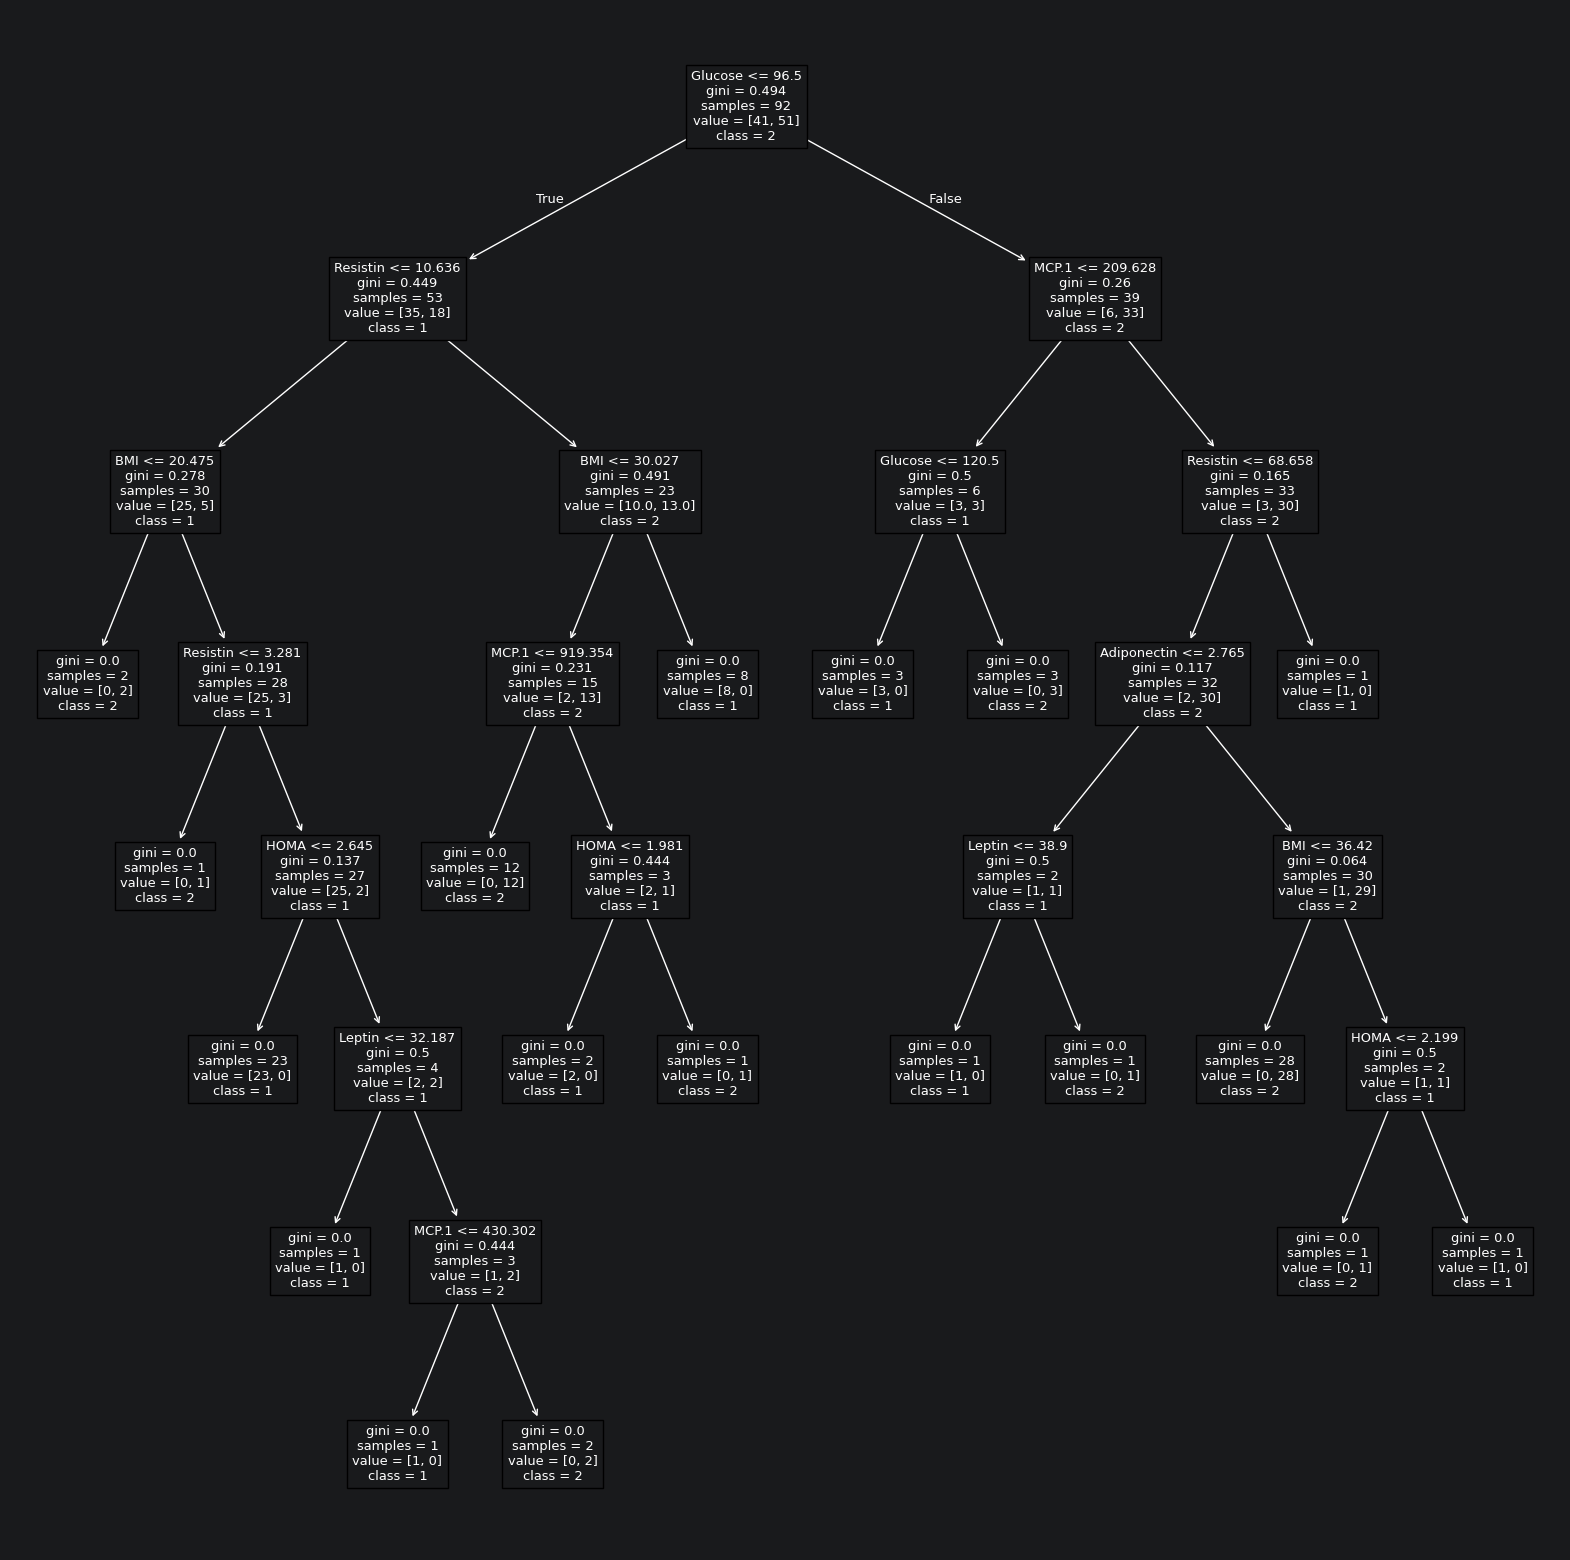

In [16]:
plt.figure(figsize=(20,20))
plot_tree(clt,feature_names=data.columns,class_names=["1","2"])
plt.show()

In [17]:
y_pred = clt.predict(x_test)

In [18]:
accuracy_score(y_test,y_pred)

0.5416666666666666

In [19]:
confusion_matrix(y_test,y_pred)

array([[6, 5],
       [6, 7]])

In [20]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.50      0.55      0.52        11
           2       0.58      0.54      0.56        13

    accuracy                           0.54        24
   macro avg       0.54      0.54      0.54        24
weighted avg       0.55      0.54      0.54        24



Pruning

In [21]:
clt1=DecisionTreeClassifier(max_depth=3)
clt1.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

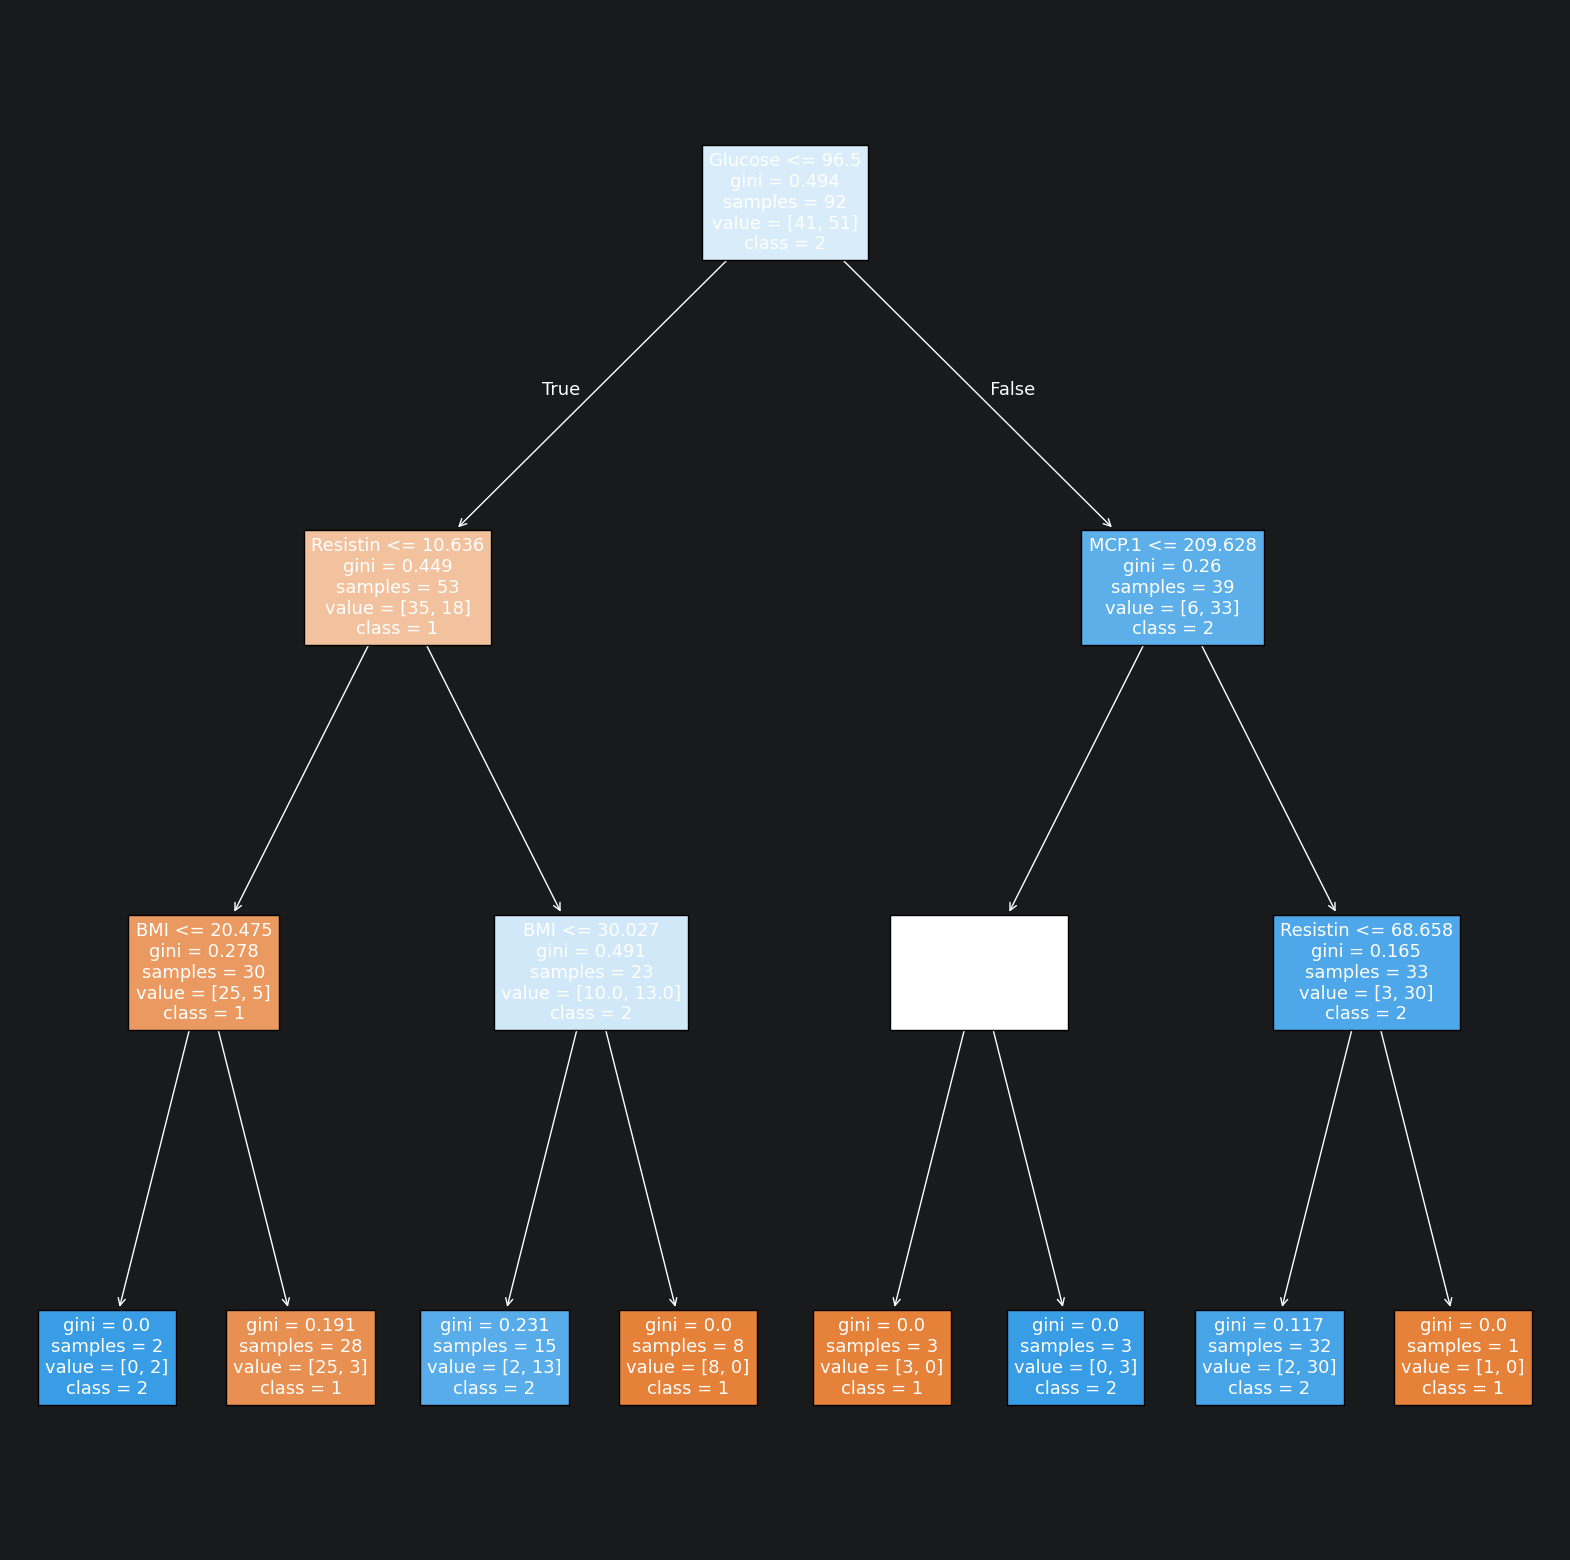

In [22]:
plt.figure(figsize=(20,20))
plot_tree(clt1,feature_names=data.columns,class_names=["1","2"],filled=True)
plt.show()

In [23]:
y_pred=clt1.predict(x_test)
accuracy_score(y_test,y_pred)

0.5833333333333334

Regression Trees

In [24]:
data=pd.read_csv("Boston.csv")
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [26]:
x=data.iloc[:,:12].values
y=data.iloc[:,12].values

In [27]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [28]:
rgt=DecisionTreeRegressor(max_depth=3)
rgt.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

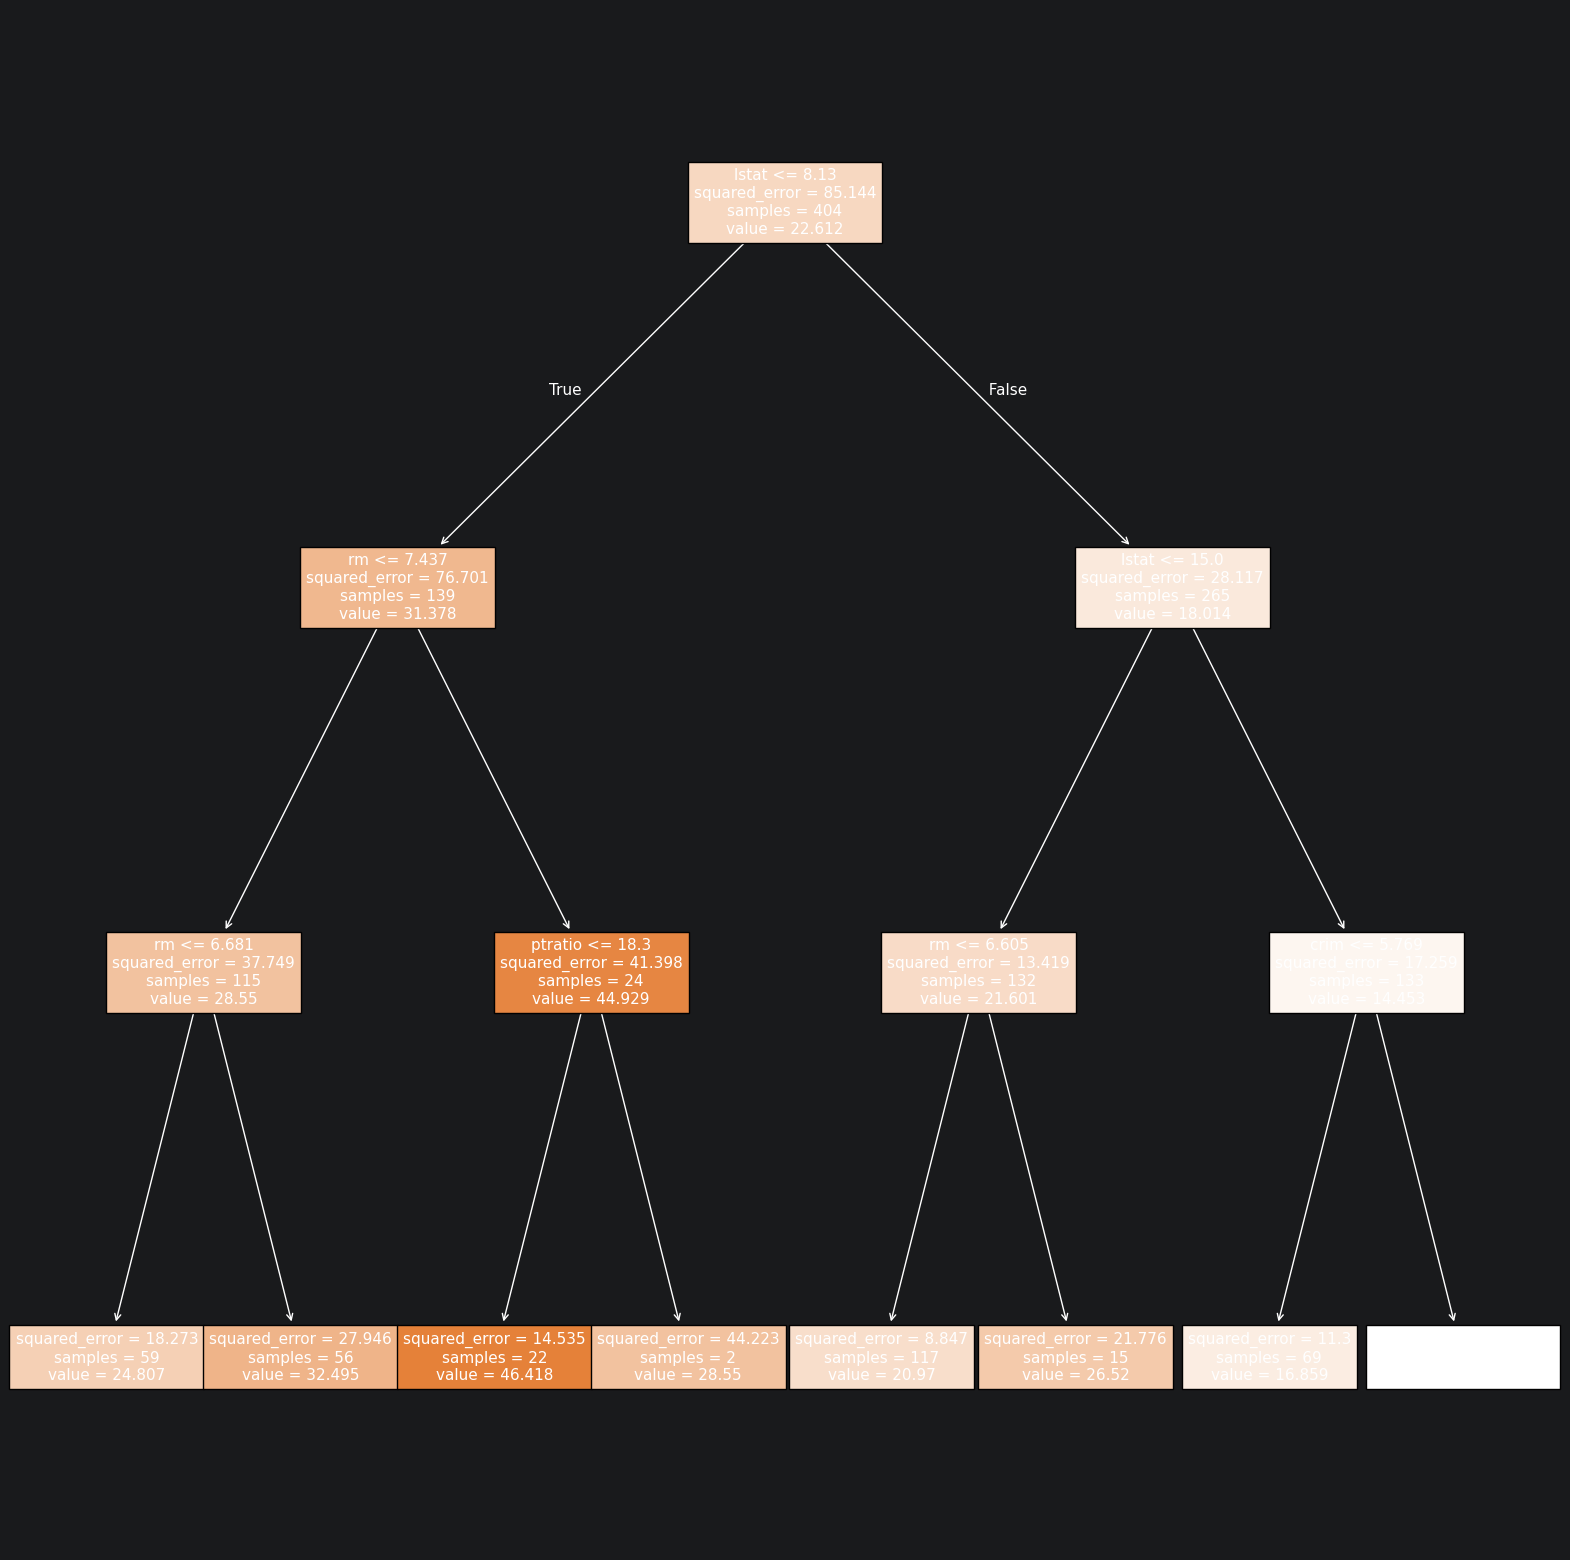

In [29]:
plt.figure(figsize=(20,20))
plot_tree(rgt,feature_names=data.columns,filled=True)
plt.show()

In [30]:
y_pred=rgt.predict(x_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(5.780248099742715)

Ensemble Techniques | Random Forest

In [34]:
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier

In [35]:
data=pd.read_csv("Bank.CSV")
data.head()

,age,duration,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,44,210,1.4,93.444,-36.1,4.963,5228.1,0
1,53,138,-0.1,93.200,-42.0,4.021,5195.8,0
2,28,339,-1.7,94.055,-39.8,0.729,4991.6,1
3,39,185,-1.8,93.075,-47.1,1.405,5099.1,0
4,55,137,-2.9,92.201,-31.4,0.869,5076.2,1


In [44]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
# Example: convert price into categories
y_train = pd.cut(y_train, bins=3, labels=["Low", "Medium", "High"])
y_test  = pd.cut(y_test, bins=3, labels=["Low", "Medium", "High"])

In [45]:
rfcl=RandomForestClassifier()
rfcl.fit(x_train,y_train)
y_pred=rfcl.predict(x_test)
accuracy_score(y_test,y_pred)

0.7745098039215687

In [47]:
from sklearn.model_selection import GridSearchCV,KFold

In [48]:
params={"n_estimators":[100,500,1000],"criterion":["gini","entropy"]}
model=RandomForestClassifier()
cval=KFold(n_splits=5)

In [49]:
gsearch=GridSearchCV(model,params,cv=cval)
results=gsearch.fit(x_train,y_train)

In [50]:
results.best_params_

{'criterion': 'gini', 'n_estimators': 100}

In [51]:
data=pd.read_csv("Boston.CSV")
data.head()

,crim,zn,indus,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [52]:
x=data.iloc[:,:12].values
y=data.iloc[:,12].values

In [53]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [54]:
rfrg=RandomForestRegressor()
rfrg.fit(x_train,y_train)
y_pred=rfrg.predict(x_test)
np.sqrt(mean_squared_error(y_test,y_pred))

np.float64(4.247682076098428)

Unsupervised Learning

In [58]:
from sklearn.cluster import KMeans

In [55]:
data=pd.read_csv("Wine.CSV")
data.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280 or OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


K-Means Clustering

In [56]:
data.iloc[:,0].values

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3])

In [57]:
x=data.iloc[:,1:]

In [59]:
kmc=KMeans(n_clusters=3)

In [60]:
kmc.fit(x)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [61]:
kmc.labels_

array([1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2,
       2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 2, 0, 2, 0, 0, 2,
       0, 0, 2, 2, 2, 0, 0, 1, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0, 0,
       2, 2, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 2, 2, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2,
       2, 2, 0, 2, 2, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0], dtype=int32)

In [62]:
kmc.inertia_

2370689.686782968

In [63]:
D=[]
K=np.arange(1,16)

for i in K:
    model=KMeans(n_clusters=i)
    model.fit(x)
    D.append(model.inertia_)

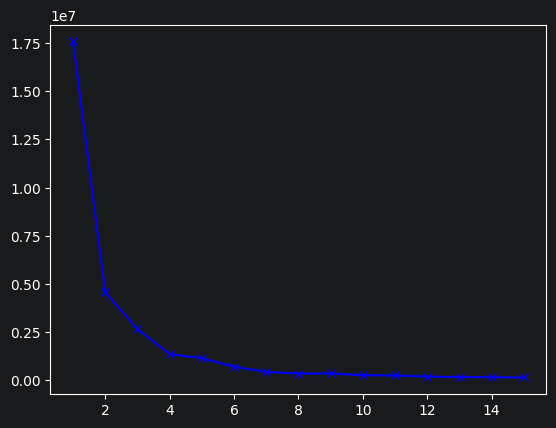

In [64]:
plt.plot(K,D,"bx-")
plt.show()

Hierarchical Clustering

In [68]:
import scipy.cluster.hierarchy as sch

In [65]:
data=pd.read_csv("Shopping.CSV")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [66]:
x=data.iloc[:,3:].values

In [70]:
result=sch.linkage(x,method="ward")

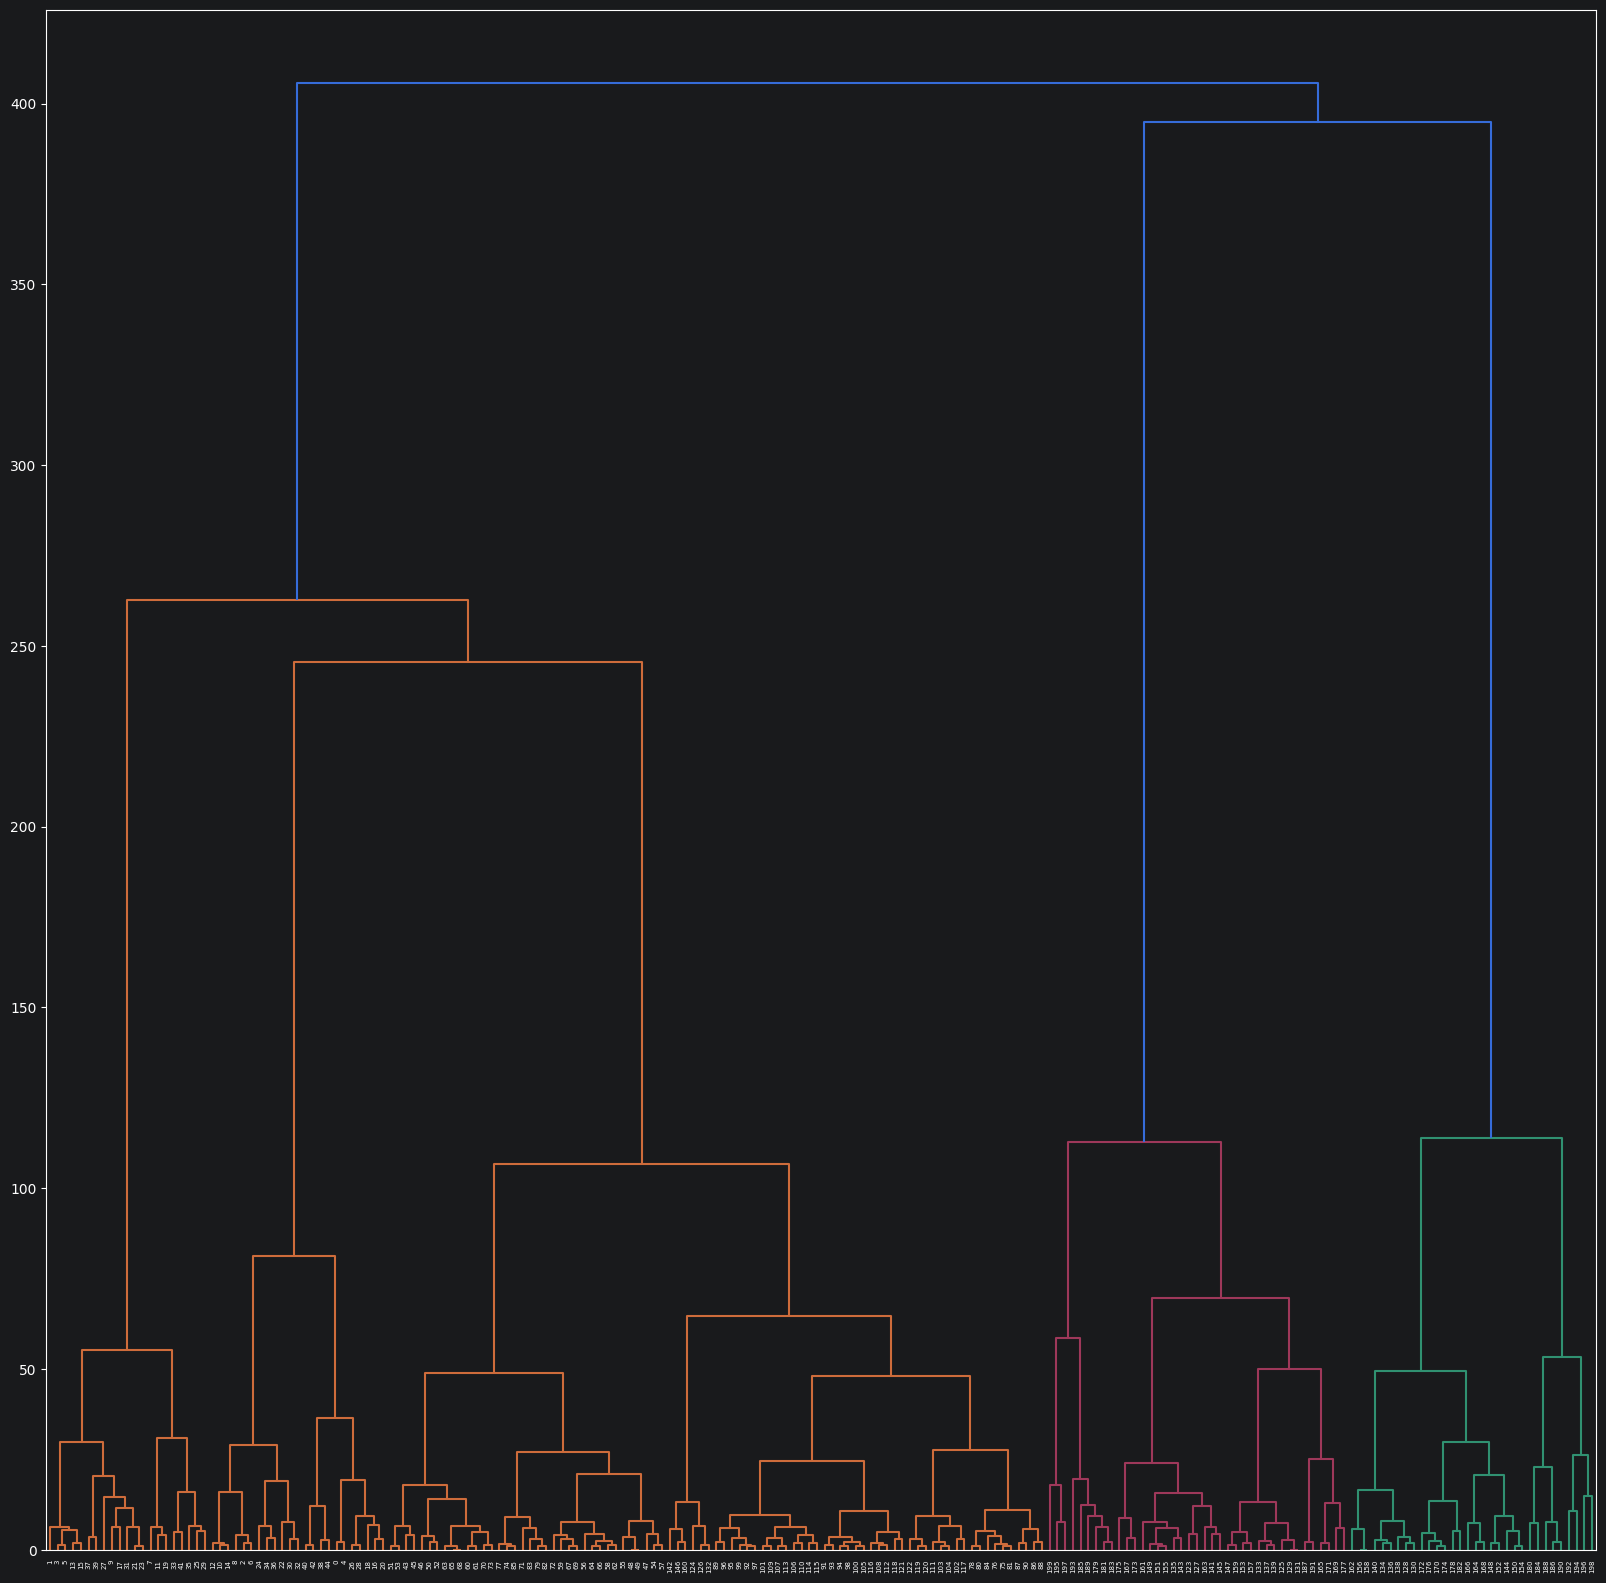

In [71]:
plt.figure(figsize=(20,20))
sch.dendrogram(result)
plt.show()

In [77]:
from sklearn.cluster import AgglomerativeClustering

In [79]:
agg=AgglomerativeClustering(n_clusters=5,metric="euclidean",linkage="ward")

In [80]:
agg.fit(x)

,"n_clusters n_clusters: int or None, default=2The number of clusters to find. It must be ``None`` if``distance_threshold`` is not ``None``.",5
,"metric metric: str or callable, default=""euclidean""Metric used to compute the linkage. Can be ""euclidean"", ""l1"", ""l2"",""manhattan"", ""cosine"", or ""precomputed"". If linkage is ""ward"", only""euclidean"" is accepted. If ""precomputed"", a distance matrix is neededas input for the fit method. If connectivity is None, linkage is""single"" and affinity is not ""precomputed"" any valid pairwise distancemetric can be assigned.For an example of agglomerative clustering with different metrics, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_clustering_metrics.py`... versionadded:: 1.2",'euclidean'
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the output of the computation of the tree.By default, no caching is done. If a string is given, it is thepath to the caching directory.",None
,"connectivity connectivity: array-like, sparse matrix, or callable, default=NoneConnectivity matrix. Defines for each sample the neighboringsamples following a given structure of the data.This can be a connectivity matrix itself or a callable that transformsthe data into a connectivity matrix, such as derived from`kneighbors_graph`. Default is ``None``, i.e, thehierarchical clustering algorithm is unstructured.For an example of connectivity matrix using:class:`~sklearn.neighbors.kneighbors_graph`, see:ref:`sphx_glr_auto_examples_cluster_plot_ward_structured_vs_unstructured.py`.",None
,"compute_full_tree compute_full_tree: 'auto' or bool, default='auto'Stop early the construction of the tree at ``n_clusters``. This isuseful to decrease computation time if the number of clusters is notsmall compared to the number of samples. This option is useful onlywhen specifying a connectivity matrix. Note also that when varying thenumber of clusters and using caching, it may be advantageous to computethe full tree. It must be ``True`` if ``distance_threshold`` is not``None``. By default `compute_full_tree` is ""auto"", which is equivalentto `True` when `distance_threshold` is not `None` or that `n_clusters`is inferior to the maximum between 100 or `0.02 * n_samples`.Otherwise, ""auto"" is equivalent to `False`.",'auto'
,"linkage linkage: {'ward', 'complete', 'average', 'single'}, default='ward'Which linkage criterion to use. The linkage criterion determines whichdistance to use between sets of observation. The algorithm will mergethe pairs of cluster that minimize this criterion.- 'ward' minimizes the variance of the clusters being merged.- 'average' uses the average of the distances of each observation of the two sets.- 'complete' or 'maximum' linkage uses the maximum distances between all observations of the two sets.- 'single' uses the minimum of the distances between all observations of the two sets... versionadded:: 0.20 Added the 'single' optionFor examples comparing different `linkage` criteria, see:ref:`sphx_glr_auto_examples_cluster_plot_linkage_comparison.py`.",'ward'
,"distance_threshold distance_threshold: float, default=NoneThe linkage distance threshold at or above which clusters will not bemerged. If not ``None``, ``n_clusters`` must be ``None`` and``compute_full_tree`` must be ``True``... versionadded:: 0.21",None
,"compute_distances compute_distances: bool, default=FalseComputes distances between clusters even if `distance_threshold` is notused. This can be used to make dendrogram visualization, but introducesa computational and memory overhead... versionadded:: 0.24For an example of dendrogram visualization, see:ref:`sphx_glr_auto_examples_cluster_plot_agglomerative_dendrogram.py`.",False


In [81]:
agg.labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

Market Basket Analysis

In [100]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [87]:
data = pd.read_excel("Online Retail.xlsx")

In [88]:
data_ger=data[data['Country']=="Germany"]

In [89]:
data.shape

(531495, 8)

In [90]:
data_ger.shape

(8668, 8)

In [93]:
bkt=data_ger.groupby(["InvoiceNo","Description"])["Quantity"].sum().unstack().fillna(0)

In [94]:
bkt=bkt.astype(int)
bkt

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,...,YULETIDE IMAGES GIFT WRAP SET,ZINC HEART T-LIGHT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536527,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536861,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536967,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581266,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581494,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
def encode_units(x):
    if x>=1:
        return 1
    else:
        return 0

In [97]:
bkt = bkt.map(encode_units)

In [98]:
bkt

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE SKULLS,...,YULETIDE IMAGES GIFT WRAP SET,ZINC HEART T-LIGHT HOLDER,ZINC STAR T-LIGHT HOLDER,ZINC BOX SIGN HOME,ZINC FOLKART SLEIGH BELLS,ZINC HEART LATTICE T-LIGHT HOLDER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC WILLIE WINKIE CANDLE STICK
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536527,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536840,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536861,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536967,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536983,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
581266,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581494,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
581570,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [106]:
ap_result=apriori(bkt,min_support=0.01,use_colnames=True)
ap_result

C:\Users\USER\PyCharmMiscProject\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
0,0.024499,frozenset({10 COLOUR SPACEBOY PEN})
1,0.022272,frozenset({12 PENCIL SMALL TUBE WOODLAND})
2,0.013363,frozenset({12 PENCILS SMALL TUBE RED RETROSPOT})
3,0.020045,frozenset({12 PENCILS TALL TUBE WOODLAND})
4,0.033408,frozenset({3 HOOK HANGER MAGIC GARDEN})
...,...,...
3966,0.011136,"frozenset({RED SPOT CERAMIC DRAWER KNOB, WHITE..."
3967,0.011136,"frozenset({REGENCY CAKESTAND 3 TIER, 6 RIBBONS..."
3968,0.011136,"frozenset({RED SPOT CERAMIC DRAWER KNOB, WHITE..."
3969,0.011136,"frozenset({REGENCY CAKESTAND 3 TIER, RED SPOT ..."


In [103]:
rules=association_rules(ap_result,metric="lift",min_threshold=1)

In [104]:
rules[(rules["lift"]>=3) & (rules["confidence"]>=0.5)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,frozenset({10 COLOUR SPACEBOY PEN}),frozenset({SPACEBOY LUNCH BOX}),0.024499,0.104677,0.013363,0.545455,5.210832,1.0,0.010799,1.969710,0.828387,0.115385,0.492311,0.336557
5,frozenset({12 PENCILS TALL TUBE WOODLAND}),frozenset({ROUND SNACK BOXES SET OF4 WOODLAND}),0.020045,0.249443,0.015590,0.777778,3.118056,1.0,0.010590,3.377506,0.693182,0.061404,0.703924,0.420139
26,frozenset({SET OF 20 KIDS COOKIE CUTTERS}),frozenset({3 PIECE SPACEBOY COOKIE CUTTER SET}),0.020045,0.042316,0.011136,0.555556,13.128655,1.0,0.010288,2.154788,0.942727,0.217391,0.535917,0.409357
38,frozenset({36 PENCILS TUBE WOODLAND}),frozenset({WOODLAND CHARLOTTE BAG}),0.026726,0.129176,0.013363,0.500000,3.870690,1.0,0.009911,1.741648,0.762014,0.093750,0.425831,0.301724
48,frozenset({6 GIFT TAGS 50'S CHRISTMAS}),frozenset({6 GIFT TAGS VINTAGE CHRISTMAS}),0.020045,0.022272,0.011136,0.555556,24.944444,1.0,0.010689,2.199889,0.979545,0.357143,0.545432,0.527778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17760,"frozenset({BLUE SPOT CERAMIC DRAWER KNOB, RED ...",frozenset({WHITE SPOT BLUE CERAMIC DRAWER KNOB...,0.020045,0.011136,0.011136,0.555556,49.888889,1.0,0.010913,2.224944,1.000000,0.555556,0.550551,0.777778
17761,"frozenset({BLUE SPOT CERAMIC DRAWER KNOB, ROUN...",frozenset({WHITE SPOT BLUE CERAMIC DRAWER KNOB...,0.015590,0.015590,0.011136,0.714286,45.816327,1.0,0.010893,3.445434,0.993665,0.555556,0.709761,0.714286
17762,"frozenset({BLUE SPOT CERAMIC DRAWER KNOB, WHIT...","frozenset({RED STRIPE CERAMIC DRAWER KNOB, ROU...",0.022272,0.017817,0.011136,0.500000,28.062500,1.0,0.010739,1.964365,0.986333,0.384615,0.490930,0.562500
17764,"frozenset({RED STRIPE CERAMIC DRAWER KNOB, WHI...","frozenset({BLUE SPOT CERAMIC DRAWER KNOB, ROUN...",0.020045,0.013363,0.011136,0.555556,41.574074,1.0,0.010868,2.219933,0.995909,0.500000,0.549536,0.694444


Reinforcement Learning – Q Learning

In [114]:
import gymnasium as gym
import numpy as np


In [120]:
env = gym.make("Taxi-v3", render_mode="rgb_array").env

In [125]:
env.observation_space.n

np.int64(500)

In [126]:
env.action_space.n

np.int64(6)

In [129]:
q_table=np.zeros((500,6))
q_table

array([[0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.]], shape=(500, 6))

In [130]:
alpha=0.1
gamma=0.6

In [138]:
for episode in np.arange(100000):
    state, info = environment.reset()
    reward=0
    terminated=False

    while not terminated:
        action=np.argmax(q_table[state])
        next_state, reward, terminated, truncated, info=environment.step(action)
        q_value=q_table[state,action]
        max_value=np.max(q_table[next_state])

        new_q_value=(1-alpha)*q_value+alpha*(reward+gamma*max_value)
        q_table[state,action]=new_q_value
        state=next_state

In [139]:
print(q_table)

[[ 0.          0.          0.          0.          0.          0.        ]
 [-2.30416297 -2.30104427 -2.29612015 -2.30104427 -2.27325184 -2.8816    ]
 [-1.62134066 -1.59900821 -1.61711908 -1.59900821 -0.7504     -1.96      ]
 ...
 [-1.02949658 -1.02201342 -1.02949658 -1.09255942 -1.96       -1.96      ]
 [-2.03112124 -2.02355093 -2.03112124 -2.03589486 -2.8816     -2.8816    ]
 [-0.196      -0.196      -0.196      -0.07       -1.         -1.        ]]
